In [8]:
%matplotlib widget
import sys
sys.path.append('/home/jack/Dev/candles-bot/scripts')
import importlib, smc_features
importlib.reload(smc_features)
from smc_features import *

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.animation as animation
from matplotlib.patches import Rectangle
from matplotlib.lines   import Line2D
from sklearn.preprocessing import RobustScaler
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
print("Prêt !")

Device : cuda
Prêt !


In [9]:
# Charger les données
SYMBOL = "EURUSD=X"
df_1h_raw = yf.download(SYMBOL, period="729d",
                         interval='1h', progress=False)
df_1h_raw.columns = [col[0] for col in df_1h_raw.columns]

# Pipeline complet
df_1d_raw = yf.download(SYMBOL, start="2020-01-01",
                         interval='1d', progress=False)
df_1d_raw.columns = [col[0] for col in df_1d_raw.columns]
df_4h_raw = yf.download(SYMBOL, period="729d",
                         interval='4h', progress=False)
df_4h_raw.columns = [col[0] for col in df_4h_raw.columns]

df_1d = build_pipeline(df_1d_raw, '1D')
df_4h = build_pipeline(df_4h_raw, '4H')
df_1h = build_pipeline(df_1h_raw, '1H')
df_mtf = align_timeframes(df_1d, df_4h, df_1h)

# Features
features_ok_cols = [
    'RSI_score_1H','RSI_7_1H','RSI_14_1H','RSI_21_1H',
    'RSI_score_4H','RSI_7_4H','RSI_14_4H',
    'RSI_score_1D','RSI_7_1D','RSI_14_1D',
    'ssl_distance_1H','bsl_distance_1H',
    'near_ssl_1H','near_bsl_1H',
    'ob_bullish_1H','ob_bearish_1H',
    'fvg_bullish_1H','fvg_bearish_1H',
    'choch_bullish_1H','choch_bearish_1H',
    'liq_sweep_bull_1H','liq_sweep_bear_1H',
    'ssl_distance_4H','bsl_distance_4H',
    'ob_bullish_4H','ob_bearish_4H',
    'choch_bullish_4H','choch_bearish_4H',
    'liq_sweep_bull_4H','liq_sweep_bear_4H',
    'ssl_distance_1D','bsl_distance_1D',
    'ob_bullish_1D','ob_bearish_1D',
    'choch_bullish_1D','liq_sweep_bull_1D',
    'CVD_norm_1H','div_bull_cvd_1H','div_bear_cvd_1H',
    'CVD_norm_4H','div_bull_cvd_4H','div_bear_cvd_4H',
    'CVD_norm_1D','div_bull_cvd_1D','div_bear_cvd_1D',
    'ATR_norm_1H','high_vol_1H','low_vol_1H',
    'ATR_norm_4H','high_vol_4H',
    'ATR_norm_1D','high_vol_1D',
    'kz_multiplier_1H','in_kill_zone_1H',
    'kz_london_1H','kz_ny_1H',
]
features_ok_cols = [f for f in features_ok_cols
                    if f in df_mtf.columns]

df_clean = df_mtf[features_ok_cols + ['Close']].dropna()

# Normaliser
scaler = RobustScaler()
scaler.fit(df_clean[features_ok_cols])

print(f"Données prêtes : {len(df_clean)} bougies")
print(f"Features       : {len(features_ok_cols)}")


Pipeline 1D...
  Kill Zones   : (1648, 13)
  RSI Ribbon   : (1648, 18)
  SMC Features : (1629, 32)
  ATR + CVD    : (1580, 45)
  Shape final  : (1580, 45)
  Période      : 2020-04-06 → 2026-05-01

Pipeline 4H...
  Kill Zones   : (4359, 13)
  RSI Ribbon   : (4359, 18)
  SMC Features : (4340, 32)
  ATR + CVD    : (4163, 45)
  Shape final  : (4163, 45)
  Période      : 2023-08-02 → 2026-05-01

Pipeline 1H...
  Kill Zones   : (17248, 13)
  RSI Ribbon   : (17248, 18)
  SMC Features : (17229, 32)
  ATR + CVD    : (11115, 45)
  Shape final  : (11115, 45)
  Période      : 2023-07-20 → 2026-05-01
Alignement des timeframes...
Shape fusionné : (11013, 125)
Période        : 2023-08-02 → 2026-05-01
Données prêtes : 11013 bougies
Features       : 56


In [10]:
# Redéfinir les architectures
class AttentionLayer(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.Tanh(),
            nn.Linear(hidden_size // 2, 1)
        )
    def forward(self, x):
        scores  = self.attention(x)
        weights = torch.softmax(scores, dim=1)
        context = (weights * x).sum(dim=1)
        return context, weights

class BiLSTMContext_v2(nn.Module):
    def __init__(self, input_size, hidden=64,
                 dropout=0.3, embed_size=32):
        super().__init__()
        self.bilstm = nn.LSTM(
            input_size, hidden, num_layers=2,
            batch_first=True, bidirectional=True,
            dropout=dropout)
        self.norm         = nn.LayerNorm(hidden * 2)
        self.dropout      = nn.Dropout(dropout)
        self.trend_head   = nn.Linear(hidden * 2, 3)
        self.amd_head     = nn.Linear(hidden * 2, 2)
        self.context_head = nn.Sequential(
            nn.Linear(hidden * 2, embed_size), nn.Tanh())
    def forward(self, x):
        out, _    = self.bilstm(x)
        out       = self.norm(out)
        out       = self.dropout(out)
        last      = out[:, -1, :]
        return (self.trend_head(last),
                self.amd_head(last),
                self.context_head(last))

class TradingSystemMTF(nn.Module):
    def __init__(self, input_size, context_embed=32,
                 hidden1=64, hidden2=32, dropout=0.3):
        super().__init__()
        self.model1   = BiLSTMContext_v2(
            input_size, hidden=64,
            dropout=dropout, embed_size=context_embed)
        input2        = input_size + context_embed + 3 + 2
        self.lstm1    = nn.LSTM(input2, hidden1,
                                 batch_first=True)
        self.lstm2    = nn.LSTM(hidden1, hidden2,
                                 batch_first=True)
        self.attention= AttentionLayer(hidden2)
        self.norm1    = nn.LayerNorm(hidden1)
        self.norm2    = nn.LayerNorm(hidden2)
        self.dropout  = nn.Dropout(dropout)
        self.fc1      = nn.Linear(hidden2, 32)
        self.fc2      = nn.Linear(32, 1)
        self.relu     = nn.ReLU()

    def forward(self, x):
        tlog, alog, ctx = self.model1(x)
        ts  = torch.softmax(tlog, dim=1)
        as_ = torch.softmax(alog, dim=1)
        sl  = x.shape[1]
        xe  = torch.cat([
            x,
            ctx.unsqueeze(1).expand(-1, sl, -1),
            ts.unsqueeze(1).expand(-1, sl, -1),
            as_.unsqueeze(1).expand(-1, sl, -1)
        ], dim=2)
        o1, _ = self.lstm1(xe)
        o1    = self.norm1(o1)
        o1    = self.dropout(o1)
        o2, _ = self.lstm2(o1)
        o2    = self.norm2(o2)
        o2    = self.dropout(o2)
        ctx2, _ = self.attention(o2)
        out   = self.relu(self.fc1(ctx2))
        out   = self.dropout(out)
        return self.fc2(out).squeeze()

# Charger modèle sauvegardé ou créer nouveau
import os
model_path = '/home/jack/Dev/candles-bot/models/trading_system.pt'

trading_system = TradingSystemMTF(
    input_size = len(features_ok_cols)).to(device)

if os.path.exists(model_path):
    trading_system.load_state_dict(
        torch.load(model_path, map_location=device))
    print(f"Modèle chargé : {model_path}")
else:
    print("Modèle non sauvegardé — utilisation poids actuels")
    print("Astuce : sauvegardez avec :")
    print("torch.save(trading_system.state_dict(),")
    print(f"           '{model_path}')")

trading_system.eval()
print(f"Modèle prêt sur {device}")

Modèle non sauvegardé — utilisation poids actuels
Astuce : sauvegardez avec :
torch.save(trading_system.state_dict(),
           '/home/jack/Dev/candles-bot/models/trading_system.pt')
Modèle prêt sur cuda


In [11]:
SEQ_LEN  = 60
PIP      = 0.0001
TP_PIPS  = 15
SL_PIPS  = 10
SEUIL    = 0.55

def run_backtest(df, features, scaler,
                 model, seq_len=60,
                 seuil=0.55, tp=15, sl=10):
    """
    Simule les trades bougie par bougie.
    Retourne l'historique complet pour l'animation.
    """
    n       = len(df)
    history = []
    trades  = []
    capital = 10000
    pnl     = 0
    pos     = None  # position ouverte

    X_scaled = scaler.transform(df[features])

    for i in range(seq_len, n):
        row    = df.iloc[i]
        close  = row['Close']
        date   = df.index[i]

        # Prédiction du modèle
        seq    = X_scaled[i-seq_len:i]
        tensor = torch.FloatTensor(seq).unsqueeze(0).to(device)

        with torch.no_grad():
            logit = model(tensor)
            proba = torch.sigmoid(logit).item()

        # Gestion position ouverte
        trade_result = None
        if pos is not None:
            entry  = pos['entry']
            pnl_pips = (close - entry) / PIP

            if pnl_pips >= tp:
                gain        = tp * PIP * 100000 * 0.01
                pnl        += gain
                capital    += gain
                trade_result= {
                    'type'  : 'TP',
                    'entry' : entry,
                    'exit'  : close,
                    'pips'  : tp,
                    'pnl'   : gain,
                    'date'  : date
                }
                trades.append(trade_result)
                pos = None

            elif pnl_pips <= -sl:
                loss        = sl * PIP * 100000 * 0.01
                pnl        -= loss
                capital    -= loss
                trade_result= {
                    'type'  : 'SL',
                    'entry' : entry,
                    'exit'  : close,
                    'pips'  : -sl,
                    'pnl'   : -loss,
                    'date'  : date
                }
                trades.append(trade_result)
                pos = None

        # Nouveau signal
        signal = proba > seuil and pos is None
        if signal:
            pos = {
                'entry'  : close,
                'date'   : date,
                'proba'  : proba,
                'tp'     : close + tp * PIP,
                'sl'     : close - sl * PIP
            }

        # Contexte Modèle 1
        with torch.no_grad():
            tlog, alog, _ = model.model1(tensor)
            trend_pred = tlog.argmax(1).item() - 1
            amd_pred   = alog.argmax(1).item()

        history.append({
            'idx'        : i,
            'date'       : date,
            'open'       : row.get('Open', close),
            'high'       : row.get('High', close),
            'low'        : row.get('Low',  close),
            'close'      : close,
            'proba'      : proba,
            'signal'     : signal,
            'trend'      : trend_pred,
            'amd'        : amd_pred,
            'position'   : pos.copy() if pos else None,
            'trade'      : trade_result,
            'pnl'        : pnl,
            'capital'    : capital,
            'kz'         : row.get('kz_multiplier_1H', 1.0),
            'rsi_score'  : row.get('RSI_score_1H', 0),
        })

    return history, trades

# Lancer le backtest sur les 500 dernières bougies
print("Calcul backtest...")
df_bt  = df_clean.tail(500).copy()

# Récupérer OHLC
ohlc   = df_1h_raw[['Open','High','Low','Close']].copy()
ohlc.index = pd.to_datetime(ohlc.index, utc=True)
df_bt  = df_bt.join(ohlc, how='left', rsuffix='_raw')
for col in ['Open','High','Low']:
    if f'{col}_raw' in df_bt.columns:
        df_bt[col] = df_bt[f'{col}_raw']

history, trades = run_backtest(
    df_bt, features_ok_cols, scaler,
    trading_system, SEQ_LEN, SEUIL, TP_PIPS, SL_PIPS)

print(f"Backtest terminé : {len(history)} bougies")
print(f"Trades           : {len(trades)}")
tp_trades = [t for t in trades if t['type']=='TP']
sl_trades = [t for t in trades if t['type']=='SL']
print(f"  TP : {len(tp_trades)}")
print(f"  SL : {len(sl_trades)}")
if trades:
    final_pnl = history[-1]['pnl']
    print(f"P&L final : {final_pnl:+.2f} $")

Calcul backtest...


Backtest terminé : 440 bougies
Trades           : 58
  TP : 25
  SL : 33
P&L final : +4.50 $


Lancement animation — 440 frames
Vitesse : 150ms par bougie
Fermez la fenêtre pour arrêter.



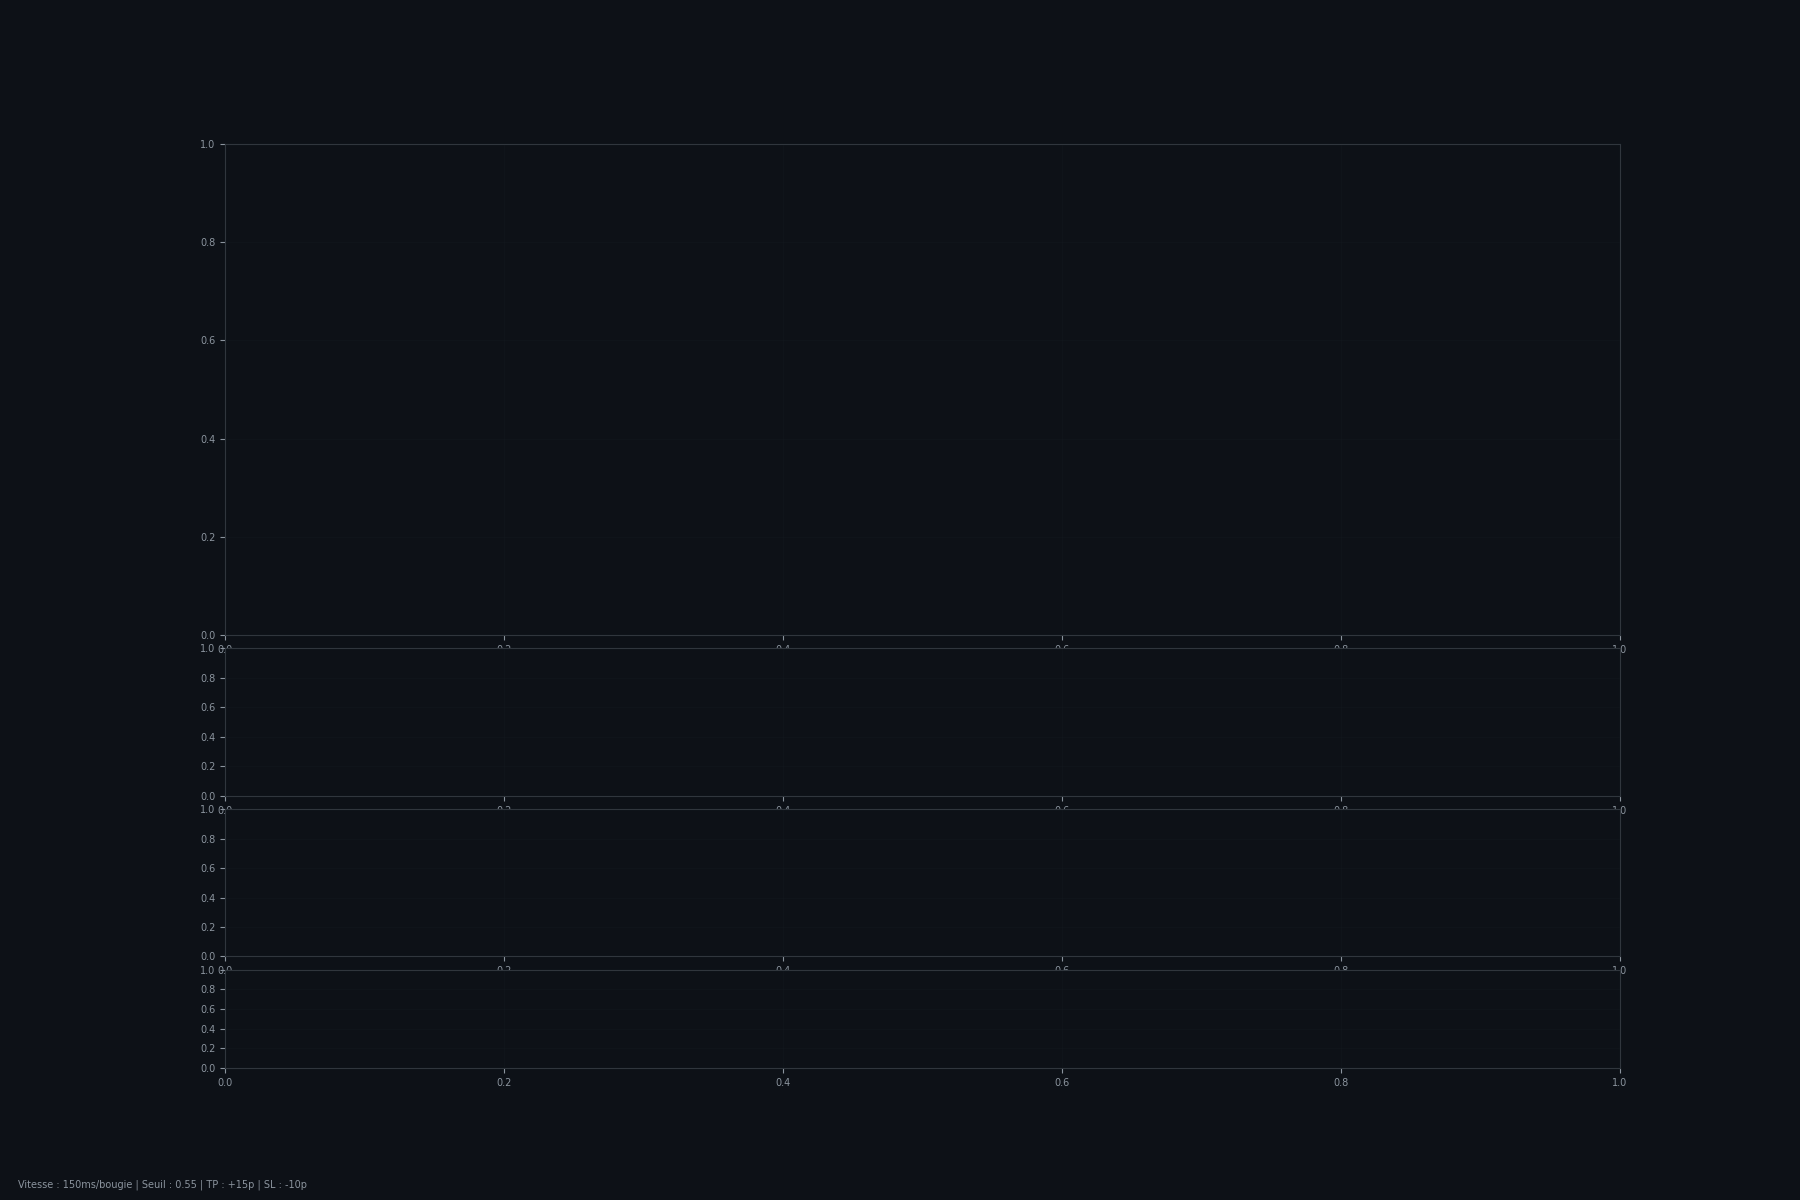

In [14]:
# Paramètres animation
N_VISIBLE = 80    # bougies visibles
INTERVAL  = 150   # ms entre chaque bougie (150=rapide)
# Changez INTERVAL : 50=très rapide, 500=lent

fig = plt.figure(figsize=(18, 12),
                  facecolor='#0d1117')
gs  = gridspec.GridSpec(
    4, 1,
    height_ratios=[5, 1.5, 1.5, 1],
    hspace=0.06,
    figure=fig)

ax1 = fig.add_subplot(gs[0])  # Prix + trades
ax2 = fig.add_subplot(gs[1])  # RSI Score
ax3 = fig.add_subplot(gs[2])  # Probabilité modèle
ax4 = fig.add_subplot(gs[3])  # P&L

for ax in [ax1, ax2, ax3, ax4]:
    ax.set_facecolor('#0d1117')
    ax.tick_params(colors='#8b949e', labelsize=7)
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')
    ax.grid(True, alpha=0.15, color='#21262d')

# Éléments dynamiques
info_text = ax1.text(
    0.02, 0.97, '', transform=ax1.transAxes,
    fontsize=8, color='#e6edf3', va='top',
    bbox=dict(boxstyle='round', facecolor='#161b22',
              alpha=0.8, edgecolor='#30363d'))

pnl_text  = ax4.text(
    0.98, 0.85, '', transform=ax4.transAxes,
    fontsize=9, color='#e6edf3', ha='right',
    fontweight='bold')

speed_text= fig.text(
    0.01, 0.01,
    f'Vitesse : {INTERVAL}ms/bougie | '
    f'Seuil : {SEUIL} | '
    f'TP : +{TP_PIPS}p | SL : -{SL_PIPS}p',
    fontsize=7, color='#8b949e')

def animate(frame):
    if frame >= len(history):
        return

    start  = max(0, frame - N_VISIBLE)
    end    = frame + 1
    window = history[start:end]
    n_w    = len(window)
    curr   = history[frame]

    # ── PANEL 1 : BOUGIES + SMC ────────────────────────────────
    ax1.cla()
    ax1.set_facecolor('#0d1117')
    ax1.grid(True, alpha=0.15, color='#21262d')

    # Rectangle contexte M1 en fond
    # Vert = uptrend + Action, Rouge = downtrend, Gris = range
    for j, h in enumerate(window):
        trend = h.get('trend', 0)
        amd   = h.get('amd', 0)
        kz    = h.get('kz', 1.0)

        if trend == 1 and amd == 1:
            bg = '#26a69a'   # uptrend + action = fort bull
        elif trend == -1 and amd == 1:
            bg = '#ef5350'   # downtrend + action = fort bear
        elif trend == 1:
            bg = '#26a69a'   # uptrend
        elif trend == -1:
            bg = '#ef5350'   # downtrend
        else:
            bg = '#8b949e'   # range

        # Opacité selon Kill Zone
        alpha = 0.12 if kz >= 2.5 else 0.05
        ax1.axvspan(j-0.5, j+0.5,
                   alpha=alpha, color=bg, zorder=0)

    # Bougies
    closes = []
    for j, h in enumerate(window):
        o  = h.get('open',  h['close'])
        hi = h.get('high',  h['close'])
        lo = h.get('low',   h['close'])
        c  = h['close']
        closes.append(c)
        color = '#26a69a' if c >= o else '#ef5350'
        ax1.bar(j, abs(c-o), bottom=min(o,c),
                color=color, width=0.7,
                alpha=0.9, zorder=2)
        ax1.plot([j,j],[lo,hi],
                 color=color, linewidth=0.8, zorder=2)

    if not closes:
        return

    price_min = min(closes) * 0.9995
    price_max = max(closes) * 1.0005

    # ── SSL / BSL ──────────────────────────────────────────────
    ssl_vals = []
    bsl_vals = []
    for h in window:
        row_idx = df_bt.index.get_loc(h['date']) \
                  if h['date'] in df_bt.index else None
        if row_idx is not None:
            ssl = df_bt.iloc[row_idx].get(
                'swing_low_1H',
                df_bt.iloc[row_idx].get('swing_low', np.nan))
            bsl = df_bt.iloc[row_idx].get(
                'swing_high_1H',
                df_bt.iloc[row_idx].get('swing_high', np.nan))
        else:
            ssl = np.nan
            bsl = np.nan
        ssl_vals.append(ssl)
        bsl_vals.append(bsl)

    ssl_clean = [v for v in ssl_vals if not np.isnan(v)]
    bsl_clean = [v for v in bsl_vals if not np.isnan(v)]

    if ssl_clean:
        ax1.plot(range(n_w),
                 [v if not np.isnan(v) else np.nan
                  for v in ssl_vals],
                 color='#ef5350', linewidth=1.0,
                 linestyle='--', alpha=0.7,
                 label='SSL', zorder=3)
    if bsl_clean:
        ax1.plot(range(n_w),
                 [v if not np.isnan(v) else np.nan
                  for v in bsl_vals],
                 color='#26a69a', linewidth=1.0,
                 linestyle='--', alpha=0.7,
                 label='BSL', zorder=3)

    # ── ORDER BLOCKS ───────────────────────────────────────────
    ob_zones = compute_zones(
        df_bt.iloc[start:end+20],
        max_len_strong=15,
        max_len_weak=5)

    for z in ob_zones:
        if z['type'] not in ['OB↑','OB↓']:
            continue
        xs = z['start'] - start
        xe = min(z['end'] - start, n_w - 1)
        if xs < 0 or xs >= n_w:
            continue
        xe = max(xs + 1, xe)

        a_fill = 0.06 if z['mitigated'] else 0.20
        a_edge = 0.3  if z['mitigated'] else 0.85
        lstyle = ':'  if z['mitigated'] else '-'

        rect = Rectangle(
            (xs, z['bottom']),
            xe - xs,
            z['top'] - z['bottom'],
            linewidth=0.8,
            edgecolor=z['color'],
            facecolor=z['color'],
            alpha=a_fill,
            linestyle=lstyle,
            zorder=1)
        ax1.add_patch(rect)

        ax1.plot([xs, xe], [z['top'],    z['top']],
                 color=z['color'], linewidth=0.8,
                 linestyle=lstyle, alpha=a_edge, zorder=3)
        ax1.plot([xs, xe], [z['bottom'], z['bottom']],
                 color=z['color'], linewidth=0.8,
                 linestyle=lstyle, alpha=a_edge, zorder=3)

        status = '✓' if z['mitigated'] else ''
        ax1.text(xe + 0.2,
                 (z['top'] + z['bottom']) / 2,
                 f"{z['type']}{status}",
                 fontsize=6, color=z['color'],
                 alpha=a_edge, va='center', zorder=4)

    # ── POSITION OUVERTE ───────────────────────────────────────
    if curr['position'] is not None:
        pos = curr['position']
        ax1.axhline(pos['entry'],
                   color='#EF9F27', linewidth=1.2,
                   linestyle='-', alpha=0.9, zorder=4)
        ax1.axhline(pos['tp'],
                   color='#26a69a', linewidth=0.8,
                   linestyle='--', alpha=0.8, zorder=4)
        ax1.axhline(pos['sl'],
                   color='#ef5350', linewidth=0.8,
                   linestyle='--', alpha=0.8, zorder=4)
        ax1.text(n_w - 1, pos['entry'],
                f" LONG {pos['proba']:.0%}",
                color='#EF9F27', fontsize=7,
                va='center', zorder=5)
        ax1.text(n_w - 1, pos['tp'],
                f" TP +{TP_PIPS}p",
                color='#26a69a', fontsize=6,
                va='center', zorder=5)
        ax1.text(n_w - 1, pos['sl'],
                f" SL -{SL_PIPS}p",
                color='#ef5350', fontsize=6,
                va='center', zorder=5)

    # ── SIGNAUX + TRADES ───────────────────────────────────────
    for j, h in enumerate(window):
        if h['signal']:
            ax1.scatter(j, h['close'] * 0.9994,
                       marker='^', s=80,
                       color='#EF9F27', zorder=5,
                       alpha=0.9)
        if h['trade'] is not None:
            t = h['trade']
            if t['type'] == 'TP':
                ax1.scatter(j, h['close'] * 1.001,
                           marker='*', s=150,
                           color='#26a69a', zorder=6)
                ax1.text(j, h['close'] * 1.0015,
                        f'+{TP_PIPS}p',
                        color='#26a69a', fontsize=7,
                        ha='center', va='bottom')
            else:
                ax1.scatter(j, h['close'] * 0.9990,
                           marker='x', s=100,
                           color='#ef5350', zorder=6)
                ax1.text(j, h['close'] * 0.9985,
                        f'-{SL_PIPS}p',
                        color='#ef5350', fontsize=7,
                        ha='center', va='top')

    # ── LÉGENDE + TITRE ────────────────────────────────────────
    trend_map   = {-1:'↓ Down', 0:'→ Range', 1:'↑ Up'}
    amd_map     = {0:'Accum',   1:'⚡Action'}
    trend_str   = trend_map.get(curr['trend'], '?')
    amd_str     = amd_map.get(curr['amd'], '?')
    kz_str      = f"🔥KZ×{curr['kz']:.1f}" \
                  if curr['kz'] >= 2.5 else ''
    date_str    = pd.Timestamp(
        curr['date']).strftime('%d/%m %Hh')

    title_str   = (f"{date_str}  │  "
                   f"Trend:{trend_str}  │  "
                   f"AMD:{amd_str}  │  "
                   f"Proba:{curr['proba']:.1%}  "
                   f"{kz_str}")
    ax1.set_title(title_str, fontsize=9,
                  color='#e6edf3', pad=6)
    ax1.set_ylabel('EUR/USD', fontsize=8,
                   color='#8b949e')
    ax1.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda v,p: f'{v:.4f}'))
    ax1.set_xlim(-1, N_VISIBLE + 4)
    ax1.set_ylim(price_min, price_max)

    leg = [
        Line2D([0],[0], color='#ef5350', linewidth=1,
               linestyle='--', label='SSL'),
        Line2D([0],[0], color='#26a69a', linewidth=1,
               linestyle='--', label='BSL'),
        mpatches.Patch(color='#26a69a', alpha=0.3,
                       label='OB↑ / Bull context'),
        mpatches.Patch(color='#ef5350', alpha=0.3,
                       label='OB↓ / Bear context'),
        Line2D([0],[0], marker='^', color='w',
               markerfacecolor='#EF9F27',
               markersize=7, label='Signal entrée'),
        Line2D([0],[0], marker='*', color='w',
               markerfacecolor='#26a69a',
               markersize=8, label=f'TP +{TP_PIPS}p'),
        Line2D([0],[0], marker='x', color='#ef5350',
               markersize=7, label=f'SL -{SL_PIPS}p'),
    ]
    ax1.legend(handles=leg, loc='upper left',
               fontsize=6, ncol=4,
               facecolor='#161b22',
               edgecolor='#30363d',
               framealpha=0.85)

    # ── PANELS 2/3/4 — inchangés ───────────────────────────────
    # RSI Score
    ax2.cla()
    ax2.set_facecolor('#0d1117')
    ax2.grid(True, alpha=0.15, color='#21262d')
    scores = [h['rsi_score'] for h in window]
    colors = ['#26a69a' if s > 0 else
              '#ef5350' if s < 0 else
              '#8b949e' for s in scores]
    ax2.bar(range(n_w), scores,
            color=colors, alpha=0.75, width=0.8)
    ax2.axhline(0, color='#8b949e',
               linewidth=0.6, linestyle='--')
    ax2.set_ylim(-3.5, 3.5)
    ax2.set_yticks([-3, 0, 3])
    ax2.set_ylabel('RSI 1H', fontsize=7,
                   color='#8b949e')
    ax2.set_xlim(-1, N_VISIBLE + 4)

    # Probabilité
    ax3.cla()
    ax3.set_facecolor('#0d1117')
    ax3.grid(True, alpha=0.15, color='#21262d')
    probas = [h['proba'] for h in window]
    pcols  = ['#26a69a' if p > SEUIL else
              '#8b949e' for p in probas]
    ax3.bar(range(n_w), probas,
            color=pcols, alpha=0.7, width=0.8)
    ax3.axhline(SEUIL, color='#EF9F27',
               linewidth=1, linestyle='--', alpha=0.8)
    ax3.set_ylim(0, 1)
    ax3.set_yticks([0, 0.5, SEUIL, 1.0])
    ax3.set_ylabel('Proba', fontsize=7,
                   color='#8b949e')
    ax3.set_xlim(-1, N_VISIBLE + 4)

    # P&L
    ax4.cla()
    ax4.set_facecolor('#0d1117')
    ax4.grid(True, alpha=0.15, color='#21262d')
    pnls      = [h['pnl'] for h in window]
    pnl_cur   = curr['pnl']
    cpnl      = '#26a69a' if pnl_cur >= 0 else '#ef5350'
    ax4.fill_between(range(n_w), pnls, 0,
                     where=[p >= 0 for p in pnls],
                     color='#26a69a', alpha=0.3)
    ax4.fill_between(range(n_w), pnls, 0,
                     where=[p < 0 for p in pnls],
                     color='#ef5350', alpha=0.3)
    ax4.plot(range(n_w), pnls,
             color=cpnl, linewidth=1.2)
    ax4.axhline(0, color='#8b949e',
               linewidth=0.6, linestyle='--')
    ax4.set_ylabel('P&L $', fontsize=7,
                   color='#8b949e')
    ax4.set_xlim(-1, N_VISIBLE + 4)

    n_tp  = sum(1 for t in trades
                if t['type']=='TP' and
                t['date'] <= curr['date'])
    n_sl  = sum(1 for t in trades
                if t['type']=='SL' and
                t['date'] <= curr['date'])
    ax4.text(0.98, 0.85,
            f"P&L:{pnl_cur:+.2f}$  "
            f"TP:{n_tp}  SL:{n_sl}",
            transform=ax4.transAxes,
            fontsize=8, color=cpnl,
            ha='right', fontweight='bold')

    step   = max(1, n_w // 8)
    ticks  = list(range(0, n_w, step))
    labels = []
    for j in ticks:
        try:
            d = pd.Timestamp(window[j]['date'])
            labels.append(d.strftime('%d/%m %Hh'))
        except:
            labels.append('')
    ax4.set_xticks(ticks)
    ax4.set_xticklabels(labels, rotation=30,
                         fontsize=6, color='#8b949e')
    for ax in [ax1, ax2, ax3]:
        ax.set_xticks([])

# Créer l'animation
print(f"Lancement animation — {len(history)} frames")
print(f"Vitesse : {INTERVAL}ms par bougie")
print("Fermez la fenêtre pour arrêter.\n")

anim = animation.FuncAnimation(
    fig,
    animate,
    frames    = len(history),
    interval  = INTERVAL,
    repeat    = False,
    blit      = False
)

plt.tight_layout()
plt.show()

In [13]:
# Pour changer la vitesse AVANT de lancer l'animation
# Modifiez INTERVAL dans la cellule 4 :

# INTERVAL = 50   → très rapide (analyse rapide)
# INTERVAL = 150  → rapide     (défaut)
# INTERVAL = 300  → moyen      (voir les détails)
# INTERVAL = 800  → lent       (analyse approfondie)
# INTERVAL = 2000 → très lent  (bougie par bougie)

# Pour sauvegarder l'animation en vidéo :
# anim.save('/home/jack/Dev/candles-bot/models/backtest.mp4',
#            writer='ffmpeg', fps=10,
#            savefig_kwargs={'facecolor':'#0d1117'})

print("Commandes disponibles :")
print("  INTERVAL = 150  → rapide")
print("  INTERVAL = 500  → moyen")
print("  INTERVAL = 2000 → bougie par bougie")
print("\nRelancez la cellule 4 avec le nouvel INTERVAL")

Commandes disponibles :
  INTERVAL = 150  → rapide
  INTERVAL = 500  → moyen
  INTERVAL = 2000 → bougie par bougie

Relancez la cellule 4 avec le nouvel INTERVAL
